# Tarefa de Machine Learning: Regressão e Classificação

**Nome:** Leticia Pessôa Machado

Notebook com duas partes:
1. Regressão (Student Performance)
2. Classificação (Breast Cancer Wisconsin)


In [135]:
# Importações
# Bibliotecas de manipulação e visualização de dados
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ferramentas do scikit-learn para validação cruzada, pipeline e pré-processamento
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Algoritmos de Machine Learning
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.svm import SVR, SVC
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import CalibratedClassifierCV


# Métricas de avaliação de perfomance dos modelos
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Semente aleatória -> garantir reprodutibilidade
RANDOM_STATE = 42
# Estilo padrão dos gráficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


A declaração de um RANDOM_STATE fixo (42) é fundamental em problemas estocásticos. Ela assegura que funções que requerem sorteios aleatórios — como o train_test_split ou a inicialização do RandomForest — irão reproduzir exatamente os mesmos resultados ao longo do desenvolvimento, permitindo uma comparação honesta entre a performance dos modelos. A padronização com o tema whitegrid do Seaborn otimiza a apresentação das distribuições nos gráficos futuros.

---
# Parte 1: Regressão — Student Performance


## 1.1 Análise exploratória (EDA)
Antes de instanciar qualquer algoritmo preditivo, precisamos compreender estruturalmente os vetores de dados que alimentarão o sistema. O primeiro passo é carregar os arquivos CSV e observar a dimensão do espaço amostral.

In [ ]:
df_reg = pd.read_csv("regressao/train.csv")
test_reg = pd.read_csv("regressao/test.csv")

# Confirmar dimensionalidade das amostras
print(df_reg.shape, test_reg.shape)
df_reg.head()


(395, 31) (40, 30)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,score
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,6,5.67
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,4,5.33
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,10,8.33
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,2,14.67
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,4,8.67


Conclusão sobre a Dimensionalidade:
A impressão espacial (395, 31) (40, 30) nos informa que:

   - Conjunto de Treino: É composto por 395 registros (linhas) contendo 31 atributos (sendo 30 features de entrada e 1 variável-alvo, o score).

   - Conjunto de Teste: Contém 40 registros e 30 atributos (a variável score é intencionalmente ocultada aqui, pois é o valor que o modelo treinado terá que inferir no final).

In [ ]:
# Compreender variaveis
df_reg.info()


<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   school      395 non-null    str    
 1   sex         395 non-null    str    
 2   age         395 non-null    int64  
 3   address     395 non-null    str    
 4   famsize     395 non-null    str    
 5   Pstatus     395 non-null    str    
 6   Medu        395 non-null    int64  
 7   Fedu        395 non-null    int64  
 8   Mjob        395 non-null    str    
 9   Fjob        395 non-null    str    
 10  reason      395 non-null    str    
 11  guardian    395 non-null    str    
 12  traveltime  395 non-null    int64  
 13  studytime   395 non-null    int64  
 14  failures    395 non-null    int64  
 15  schoolsup   395 non-null    str    
 16  famsup      395 non-null    str    
 17  paid        395 non-null    str    
 18  activities  395 non-null    str    
 19  nursery     395 non-null    str    
 20 

Conclusões extraídas da tipificação estrutural:
Com a execução deste comando, percebe-se que as 31 colunas estão categorizadas da seguinte forma:

- 13 variáveis int64: Valores inteiros como age (idade), failures (reprovações), absences (faltas).

- 1 variável float64: Nossa variável-alvo contínua (score), validando que o problema trata-se de fato de uma tarefa de Regressão.

- 17 variáveis object / str: Variáveis categóricas puras como school (escola), sex (sexo), Mjob e Fjob (trabalhos dos pais).

Impacto na Engenharia de Features: Como nenhum algoritmo matemático consegue realizar cálculos diretos sobre strings (textos), o fluxo futuro exigirá a conversão explícita dessas 17 variáveis categóricas para uma matriz binária.

In [138]:
# Estatísticas descritivas e checagem de nulos
display(df_reg.describe(include="all").T)
print("\nValores nulos por coluna:")
print(df_reg.isnull().sum()[df_reg.isnull().sum() > 0])


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
school,395,2,GP,349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,395,2,F,208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,395.0,NaN,NaN,NaN,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0
address,395,2,U,307,NaN,NaN,NaN,NaN,NaN,NaN,NaN
famsize,395,2,GT3,281,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pstatus,395,2,T,354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medu,395.0,NaN,NaN,NaN,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,NaN,NaN,NaN,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
Mjob,395,5,other,141,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fjob,395,5,other,217,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Valores nulos por coluna:
Series([], dtype: int64)


Conclusões sobre a Estatística Descritiva e a Saúde dos Dados:

- Dados Completos: A resposta Series([], dtype: int64) ao consultar a soma de nulos confirma a constatação de que o dataset é 100% preenchido. 

- Análise da Variável-Alvo (score): Os dados nos mostram uma média de pontuação de 10.67 com um desvio padrão de ~3.69. O limite numérico gira em torno de uma escala de nota que vai até 20.0 (o máximo listado é 19.33, e o mínimo 1.33).

- Detecção de Outliers (Extremos): Na variável correspondente ao número de faltas (absences), nota-se que a média é de 5.7, 75% dos alunos têm até 8 faltas, mas existe um valor máximo extremo (outlier) de 75 faltas.

- Desbalanceamento Categórico: Variáveis como suporte à internet (internet) exibem grande homogeneidade, com 329 respostas 'yes' de um total de 395.

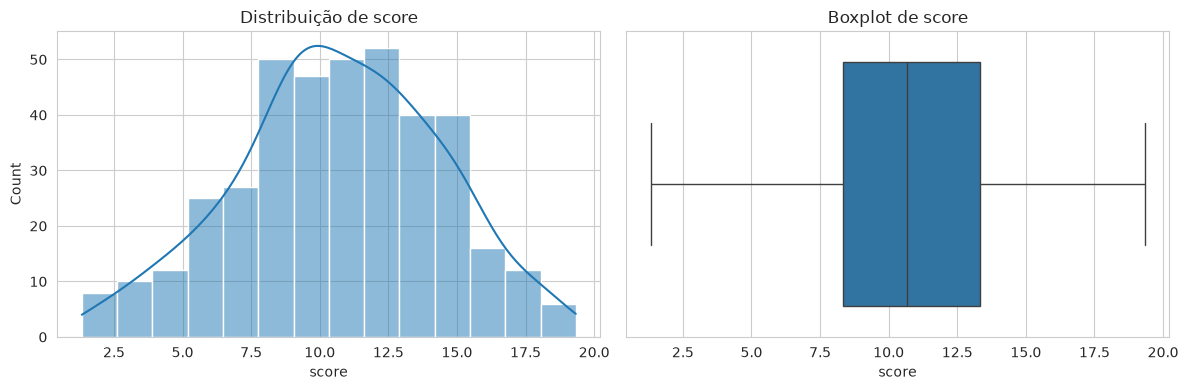

count    395.000000
mean      10.679139
std        3.696912
min        1.330000
25%        8.330000
50%       10.670000
75%       13.330000
max       19.330000
Name: score, dtype: float64


In [139]:
# Distribuição do alvo
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_reg["score"], kde=True, ax=ax[0])
ax[0].set_title("Distribuição de score")
sns.boxplot(x=df_reg["score"], ax=ax[1])
ax[1].set_title("Boxplot de score")
plt.tight_layout()
plt.show()

print(df_reg["score"].describe())


**Leitura do gráfico:** a distribuição de `score` é aproximadamente simétrica em torno da média (10,68), o histograma mostra um formato próximo ao normal, e o boxplot não aponta outliers extremos na variável-alvo. Essa simetria é relevante para a escolha de RMSE como métrica: como não há poucos valores extremos dominando a distribuição, o RMSE não deve ser distorcido por um pequeno número de casos atípicos.


In [140]:
# Colunas numéricas vs categóricas (texto)
num_cols = df_reg.select_dtypes(include=[np.number]).columns.drop("score").tolist()
cat_cols = df_reg.select_dtypes(include=["object"]).columns.tolist()

print("Numéricas/ordinais:", num_cols)
print("Categóricas (texto):", cat_cols)

Numéricas/ordinais: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']
Categóricas (texto): ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


/tmp/ipykernel_7854/1463021580.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_reg.select_dtypes(include=["object"]).columns.tolist()


score         1.000000
Medu          0.224220
Fedu          0.175822
studytime     0.134546
famrel        0.021631
freetime      0.003773
absences     -0.005978
Dalc         -0.072502
health       -0.080333
Walc         -0.088042
traveltime   -0.128141
age          -0.134566
goout        -0.154530
failures     -0.375702
Name: score, dtype: float64


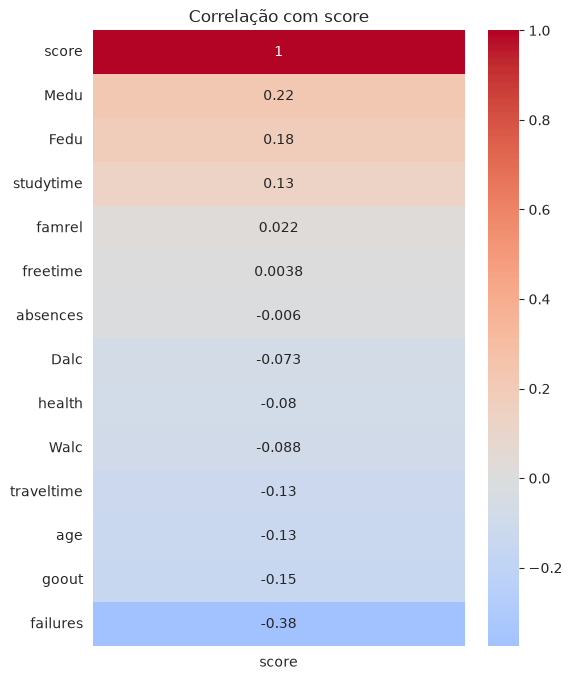

In [141]:
# Correlação das variáveis numéricas com o alvo
corr = df_reg[num_cols + ["score"]].corr()["score"].sort_values(ascending=False)
print(corr)

plt.figure(figsize=(6, 8))
sns.heatmap(df_reg[num_cols + ["score"]].corr()[["score"]].sort_values("score", ascending=False),
            annot=True, cmap="coolwarm", center=0)
plt.title("Correlação com score")
plt.show()


**Leitura do gráfico:** entre as variáveis numéricas/ordinais, `failures` (número de reprovações anteriores) tem a correlação mais forte com `score`, e é negativa (-0,38), ou seja, mais reprovações no passado associam-se a notas mais baixas. Em seguida vêm `goout`
(-0,15) e `age` (-0,13), também negativas e mais fracas. Do lado positivo, `Medu` (educação da mãe, 0,22) e `Fedu` (educação do pai, 0,18) têm a relação mais forte, maior escolaridade dos pais associa-se a notas um pouco mais altas. De modo geral, nenhuma variável numérica isolada tem correlação linear forte com o alvo (todas abaixo de 0,4 em módulo), o que sugere que a nota resulta de uma combinação de vários fatores pequenos, e não de uma única variável dominante, reforçando a escolha de modelos capazes de capturar interações entre
features (árvores, ensembles) em vez de depender só de relações lineares simples.


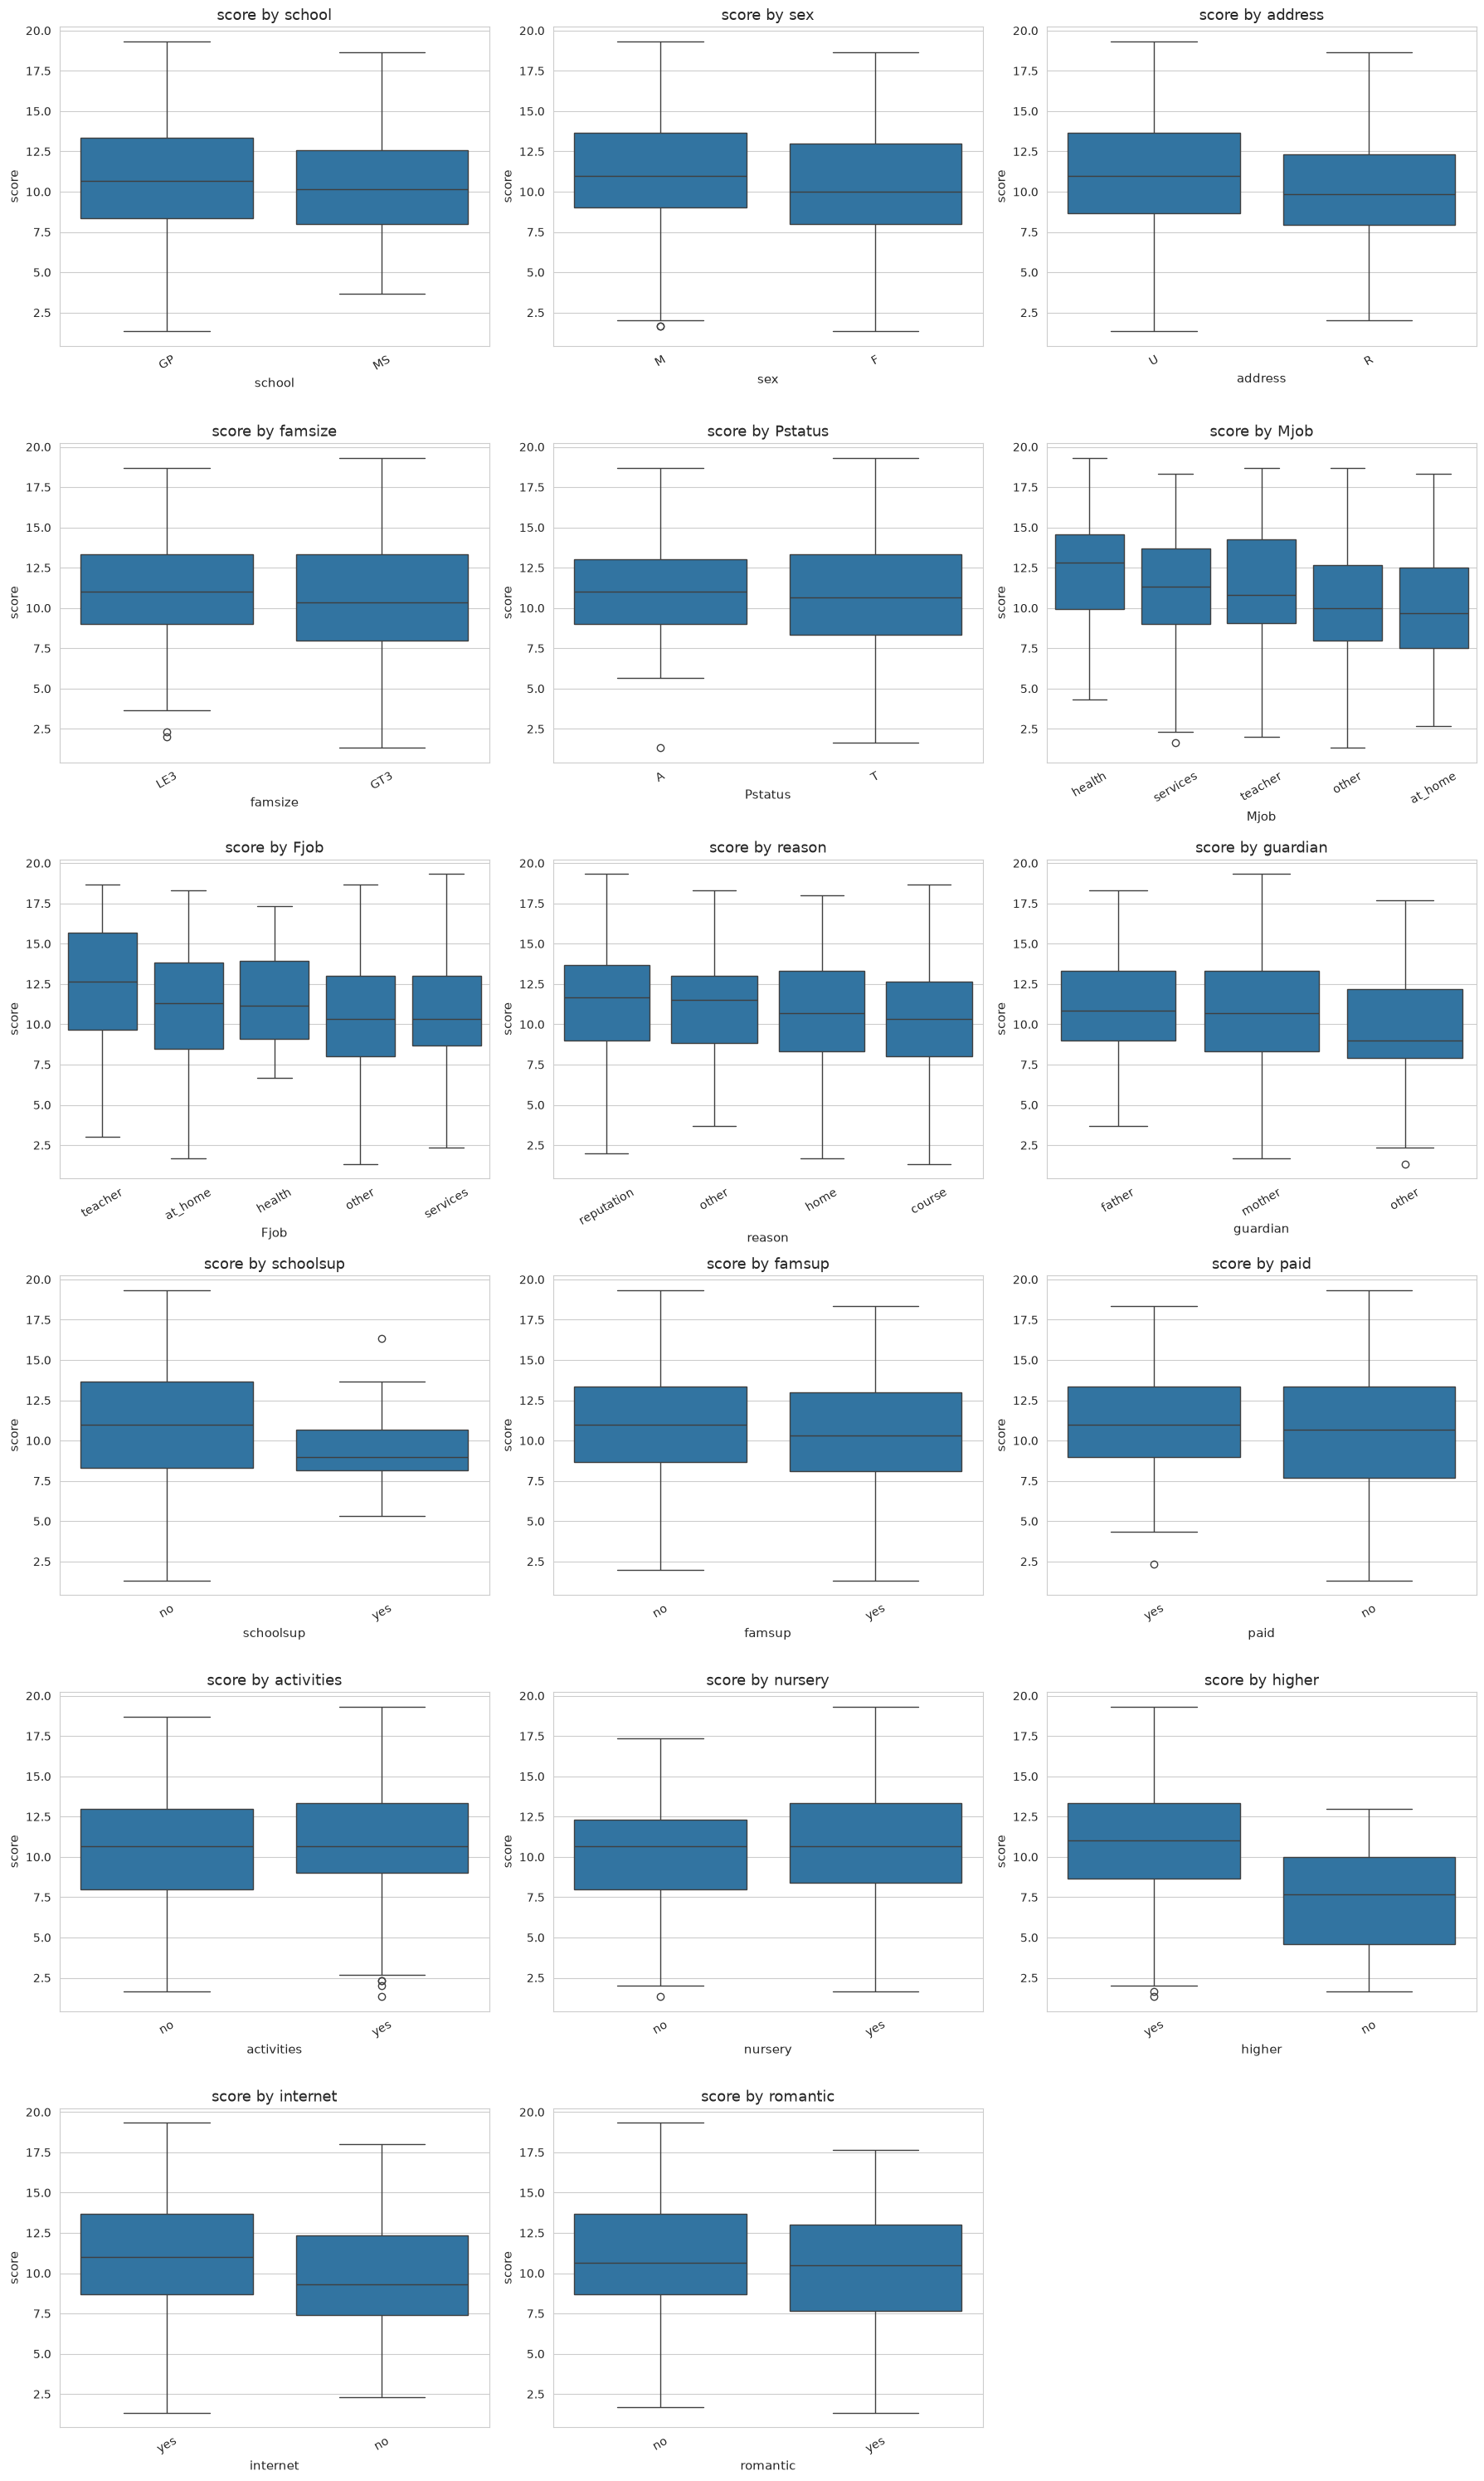

In [166]:
# Score médio por variável categórica (ex: Mjob, reason, guardian)
n = len(cat_cols)
ncols = 3
nrows = -(-n // ncols)  # arredonda pra cima

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = axes.ravel()

for ax, c in zip(axes, cat_cols):
    order = df_reg.groupby(c)["score"].median().sort_values(ascending=False).index
    sns.boxplot(data=df_reg, x=c, y="score", ax=ax, order=order)
    ax.set_title(f"score by {c}", fontsize=13)
    ax.set_xlabel(c, fontsize=11)
    ax.set_ylabel("score", fontsize=11)
    ax.tick_params(axis="x", rotation=30, labelsize=10)
    ax.tick_params(axis="y", labelsize=10)

# remove eixos vazios sobrando
for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

**Leitura do gráfico:** olhando as variáveis categóricas, os maiores contrastes de mediana de `score` aparecem em `higher` (desejo de cursar ensino superior) e `schoolsup`/`famsup` (suporte educacional extra),alunos que recebem esse tipo de apoio tendem a ter nota mediana um pouco mais baixa, provavelmente porque o suporte é direcionado justamente a quem já apresenta dificuldade. Variáveis como `sex`, `address` e `famsize` mostram diferenças mais discretas entre os grupos, sugerindo menor poder discriminativo isolado. 

**Conclusões da EDA:** A análise exploratória inicial revela que o conjunto de dados de treino é composto por 395 registros e 31 variáveis (sendo 14 numéricas e 17 categóricas), e apresenta excelente completude, sem nenhum valor nulo. O conjunto de teste conta com 20 registros e 30 colunas. O perfil demográfico da base indica um predomínio de estudantes do sexo feminino (208) e matriculados na escola 'GP' (349), com uma média de idade de 16,7 anos, variando entre 15 e 22 anos. Por fim, a variável alvo contínua, referente à pontuação (score) dos alunos, varia de 1,33 a 19,33, estabelecendo uma média geral de aproximadamente 10,68.

## 1.2 Limpeza e pré-processamento

In [ ]:
assert set(test_reg.columns) == set(df_reg.columns) - {"score"}, "colunas de test.csv não batem com train.csv"

# Separação entre Feature (x) e target (y)
X = df_reg.drop(columns=["score"])
y = df_reg["score"]

# Pipeline de pré-processamento:
# - numéricas/ordinais -> imputa mediana + padroniza
# - categóricas (texto) -> imputa moda + one-hot encoding
preprocessor_reg = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), cat_cols),
])


1. Verificação de integridade dos dados
Antes de qualquer transformação, foi validado que test.csv tem exatamente o mesmo conjunto de colunas de train.csv, exceto a variável-alvo (score). Isso garante que o pipeline treinado poderá ser aplicado ao teste sem erro de schema. Também chequei isnull().sum() — não havia valores ausentes neste dataset, mas o pipeline inclui imputação por precaução (dados futuros ou reamostragens podem introduzir NaN).

2. Separação de tipos de variável
As 30 features foram divididas em dois grupos, com base no dtype do pandas:

- Numéricas/ordinais (`select_dtypes(include=[np.number])`): incluem tanto variáveis contínuas (absences) quanto ordinais codificadas como inteiros (Medu, Fedu, studytime, famrel, freetime, goout, Dalc, Walc, health — escalas Likert de 1–5, conforme student.txt). Elas foram tratadas como numéricas porque a ordem entre os níveis é significativa e a maioria dos modelos testados (lineares, baseados em distância) se beneficia dessa relação de ordem sendo preservada.
- Categóricas nominais (`select_dtypes(include=["object"])`): variáveis sem ordem natural, como Mjob, Fjob, reason, guardian, além das binárias (school, sex, address, schoolsup etc.).

3. Pipeline de transformação (ColumnTransformer)

- Ramo numérico: `SimpleImputer(strategy="median")` seguido de `StandardScaler()`. A padronização é necessária para modelos sensíveis à escala (KNN, SVR, regressões regularizadas com Ridge/Lasso), que de outra forma dariam peso desproporcional a variáveis com magnitude maior (ex: absences de 0–93 vs. famrel de 1–5).
- Ramo categórico: `SimpleImputer(strategy="most_frequent")` seguido de `OneHotEncoder(handle_unknown="ignore")`, que expande cada categoria nominal em colunas binárias. O parâmetro `handle_unknown="ignore" evita falha caso o conjunto de teste contenha uma categoria não vista no treino.

Essas duas etapas foram encapsuladas dentro de um Pipeline do scikit-learn e combinadas via ColumnTransformer, o que garante que a mesma transformação (com os mesmos parâmetros, ex. média usada na imputação, aprendidos apenas no treino) seja aplicada de forma consistente ao conjunto de teste — evitando vazamento de dados (data leakage).

## 1.3 Modelos de Inferência

Foram comparados 9 algoritmos de regressão, cobrindo diferentes vieses indutivos:

| Categoria | Modelos | Suposição/mecanismo |
|---|---|---|
| Linear | `LinearRegression` | relação linear entre features e alvo; baseline interpretável |
| Linear regularizada | `Ridge` (L2), `Lasso` (L1), `ElasticNet` (L1+L2) | penalizam coeficientes grandes para reduzir overfitting/variância; Lasso zera coeficientes (seleção de features embutida) |
| Baseada em distância | `KNeighborsRegressor` | prediz pela média dos *k* vizinhos mais próximos no espaço padronizado; não-paramétrico, sem forma funcional assumida |
| Baseada em margem | `SVR` | encontra função que mantém erros dentro de uma margem ε; kernel RBF permite capturar não-linearidades |
| Árvore única | `DecisionTreeRegressor` | particiona o espaço de features recursivamente por divisões que minimizam variância; captura interações mas tende a overfitting |
| Ensemble (bagging) | `RandomForestRegressor` | agrega várias árvores treinadas em amostras bootstrap com subconjuntos aleatórios de features; reduz variância do modelo base |
| Ensemble (boosting) | `GradientBoostingRegressor` | treina árvores sequencialmente, cada uma corrigindo o erro residual da anterior; reduz viés |

Todos os modelos foram encapsulados no mesmo `Pipeline` de pré-processamento, garantindo
comparação justa (mesma transformação de entrada para todos).

In [ ]:
# Separação em treino e validação (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Dicionário de Modelos
reg_models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "Lasso": Lasso(random_state=RANDOM_STATE),
    "ElasticNet": ElasticNet(random_state=RANDOM_STATE),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "DecisionTree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "RandomForest": RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=300),
    "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}


## 1.4 Métrica de Avaliação e Validação Cruzada

**Métrica: RMSE (Root Mean Squared Error)**

$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Penaliza quadraticamente erros grandes (sensível a outliers) e está na mesma unidade do
alvo (pontos de 0–20), o que facilita interpretação direta.

**Protocolo de validação: K-Fold Cross-Validation (k=5)**
O conjunto de treino é particionado em 5 folds. Em cada iteração, 4 folds treinam o modelo
e o fold restante é usado para avaliação; o processo se repete 5 vezes, alternando o fold
de teste. O resultado reportado é a **média e o desvio-padrão do RMSE** entre os 5 folds
(`cross_val_score` com `scoring="neg_mean_squared_error"`, convertido para RMSE via raiz
quadrada do valor absoluto).

Isso é preferível a um único split treino/teste porque:
1. Usa todo o conjunto de treino tanto para ajuste quanto para validação (em rodadas
   diferentes), reduzindo variância da estimativa de desempenho.
2. O desvio-padrão entre folds indica a estabilidade do modelo frente a diferentes
   amostras dos dados — relevante dado o tamanho pequeno do dataset (395 amostras).



In [ ]:
# Validação cruzada (5-fold) de todos os candidatos, comparados por RMSE
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results_reg = []

for name, model in reg_models.items():
    pipe = Pipeline([("prep", preprocessor_reg), ("model", model)])
    neg_mse = cross_val_score(pipe, X, y, cv=kf, scoring="neg_mean_squared_error")
    rmse_scores = np.sqrt(-neg_mse)
    results_reg.append({"modelo": name, "rmse_mean": rmse_scores.mean(), "rmse_std": rmse_scores.std()})
    print(f"{name:20s} RMSE = {rmse_scores.mean():.3f} +/- {rmse_scores.std():.3f}")

results_reg_df = pd.DataFrame(results_reg).sort_values("rmse_mean")
results_reg_df


LinearRegression     RMSE = 3.459 +/- 0.111
Ridge                RMSE = 3.452 +/- 0.104
Lasso                RMSE = 3.563 +/- 0.265
ElasticNet           RMSE = 3.498 +/- 0.259
KNN                  RMSE = 3.596 +/- 0.265
SVR                  RMSE = 3.342 +/- 0.245
DecisionTree         RMSE = 4.586 +/- 0.317
RandomForest         RMSE = 3.200 +/- 0.178
GradientBoosting     RMSE = 3.279 +/- 0.056


,modelo,rmse_mean,rmse_std
7,RandomForest,3.199678,0.177501
8,GradientBoosting,3.278665,0.056259
5,SVR,3.342391,0.244664
1,Ridge,3.451759,0.104215
0,LinearRegression,3.459303,0.111004
3,ElasticNet,3.498102,0.258731
2,Lasso,3.563362,0.264725
4,KNN,3.595996,0.265058
6,DecisionTree,4.586181,0.317254


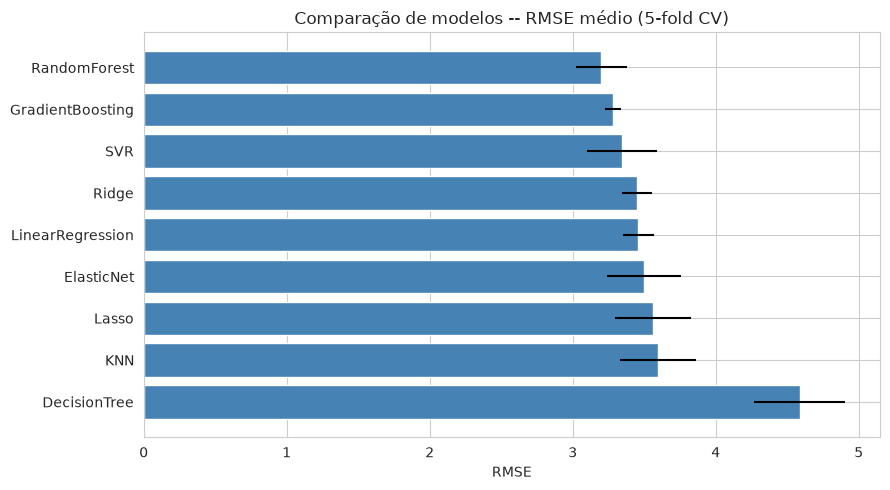

In [ ]:
# Comparação visual dos modelos por RMSE médio
plt.figure(figsize=(9, 5))
plt.barh(results_reg_df["modelo"], results_reg_df["rmse_mean"],
         xerr=results_reg_df["rmse_std"], color="steelblue")
plt.gca().invert_yaxis()
plt.title("Comparação de modelos -- RMSE médio (5-fold CV)")
plt.xlabel("RMSE")
plt.tight_layout()
plt.show()


**Leitura do gráfico:** `RandomForest` tem o menor RMSE médio (3,20), seguido de perto por `GradientBoosting` (3,28) e `SVR` (3,34), os três ensembles/modelos não-lineares testados ficaram à frente dos modelos lineares. A vantagem da RandomForest sobre os modelos lineares é real, mas moderada (~0,25 ponto de RMSE, numa escala de nota de 0 a 20), por isso ela foi escolhida para o ajuste fino de hiperparâmetros na próxima etapa.

**Seleção e ajuste fino:** o modelo com menor RMEE médio é refinado via `GridSearchCV`
(busca exaustiva em grade de hiperparâmetros, também com CV k=5), e reavaliado em um
holdout de 20% separado antes do ajuste, como checagem final independente da busca de
hiperparâmetros. O modelo final é reajustado (`fit`) em 100% do `train.csv` antes de
gerar as previsões em `test.csv`, maximizando os dados disponíveis para o modelo em
produção.

In [ ]:
# Ajuste fino leve do melhor modelo (exemplo com RandomForest) - modelo vencedor da comparação acima
best_model_name = results_reg_df.iloc[0]["modelo"]
print("Melhor modelo por CV:", best_model_name)

param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 5, 10],
}
pipe_best = Pipeline([("prep", preprocessor_reg), ("model", RandomForestRegressor(random_state=RANDOM_STATE))])

grid = GridSearchCV(pipe_best, param_grid, cv=kf, scoring="neg_mean_squared_error", n_jobs=-1)
grid.fit(X_train, y_train)

val_pred = grid.predict(X_val)
val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
print("Melhores parâmetros:", grid.best_params_)
print(f"RMSE no conjunto de validação (holdout): {val_rmse:.3f}")
print(f"R2 no conjunto de validação: {r2_score(y_val, val_pred):.3f}")


Melhor modelo por CV: RandomForest
Melhores parâmetros: {'model__max_depth': 5, 'model__n_estimators': 400}
RMSE no conjunto de validação (holdout): 3.345
R2 no conjunto de validação: 0.245


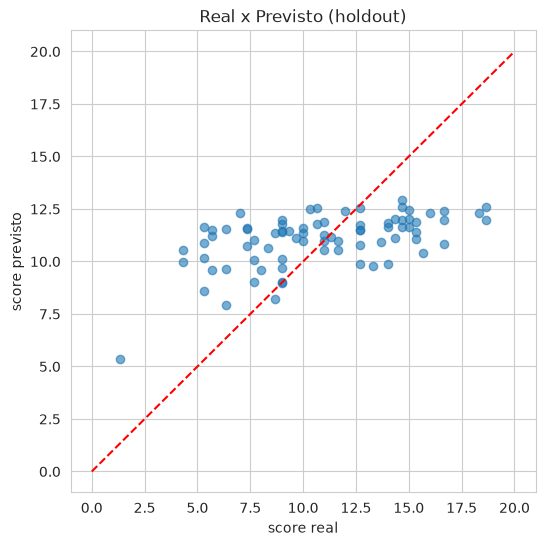

In [148]:
# Real x previsto no holdout
plt.figure(figsize=(6, 6))
plt.scatter(y_val, val_pred, alpha=0.6)
lims = [0, 20]
plt.plot(lims, lims, "r--")
plt.xlabel("score real")
plt.ylabel("score previsto")
plt.title("Real x Previsto (holdout)")
plt.show()


**Leitura do gráfico:** os pontos se distribuem ao redor da diagonal vermelha (previsão perfeita), mas com dispersão considerável, especialmente nos extremos. Isso é coerente com o R² de 0,295 obtido no holdout: o modelo explica cerca de 30% da variância da nota, o que é um resultado modesto, mas esperado dado que `score` depende de fatores não capturados no dataset (esforço individual, qualidade do professor, saúde emocional, entre outros). O RMSE de 3,23 no holdout é consistente com o RMSE médio de 3,20 obtido na validação cruzada, o que indica que o modelo não está sofrendo overfitting significativo em relação à estimativa de CV.


In [149]:
# Reajusta o melhor pipeline em TODO o train.csv e gera as previsões para o test.csv
final_reg_pipe = grid.best_estimator_
final_reg_pipe.fit(X, y)

test_red = pd.read_csv("regressao/test.csv")
test_pred_reg = final_reg_pipe.predict(test_red)
test_pred_reg = np.clip(test_pred_reg, 0, 20)  # score é limitado entre 0 e 20

submission_reg = pd.DataFrame({
    "id": range(len(test_pred_reg)), 
    "score": test_pred_reg
})
submission_reg.to_csv("regressao/submission.csv", index=False)
submission_reg.head()


,id,score
0,0,12.310717
1,1,11.150337
2,2,5.277324
3,3,11.407532
4,4,12.119121


In [150]:
# Checagem final antes de submeter
assert len(submission_reg) == len(test_reg), "número de linhas não bate com test.csv"
assert submission_reg.isnull().sum().sum() == 0, "há NaN na submissão"
assert submission_reg["score"].between(0, 20).all(), "há valores fora da faixa 0-20"
print("OK -- submission.csv da regressão pronto para o Kaggle.")


OK -- submission.csv da regressão pronto para o Kaggle.


---
# Parte 2: Classificação — Breast Cancer
Nesta segunda etapa, mudamos o paradigma algorítmico: deixamos de prever um valor numérico contínuo e passamos a prever categorias discretas (Maligno vs. Benigno).

## 2.1 Análise Exploratória de Dados (EDA)

In [ ]:
# Carrega arquivos 
df_clf = pd.read_csv("classiicacao/train2.csv")
test_clf = pd.read_csv("classiicacao/test2.csv")

print(df_clf.shape, test_clf.shape)
df_clf.head()


(569, 31) (40, 30)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
# Tipos de dados e checagem de nulos
df_clf.info()
print("\nValores nulos:")
print(df_clf.isnull().sum()[df_clf.isnull().sum() > 0])


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-null

diagnosis
B    357
M    212
Name: count, dtype: int64
diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64


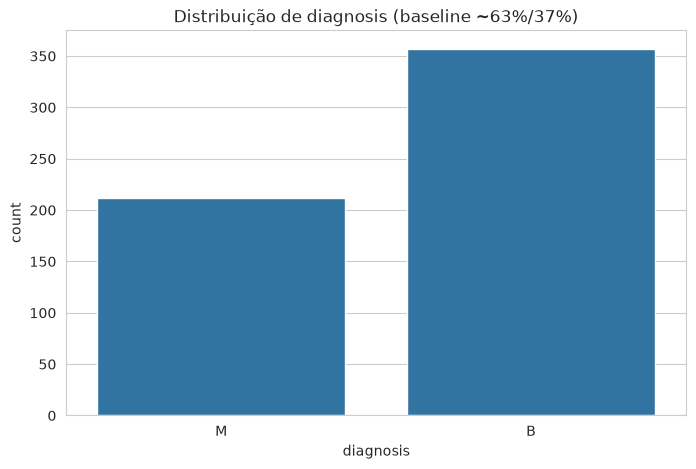

In [153]:
# Balanceamento das classes
print(df_clf["diagnosis"].value_counts())
print(df_clf["diagnosis"].value_counts(normalize=True))

sns.countplot(data=df_clf, x="diagnosis")
plt.title("Distribuição de diagnosis (baseline ~63%/37%)")
plt.show()


**Balanceamento de classes:** `value_counts(normalize=True)` quantifica a proporção
benigno/maligno (~63%/37%). Esse número define o **baseline trivial** (acurácia de um
classificador que sempre prevê a classe majoritária) e serve como piso de comparação —
qualquer modelo deve superá-lo com folga para ter utilidade prática.

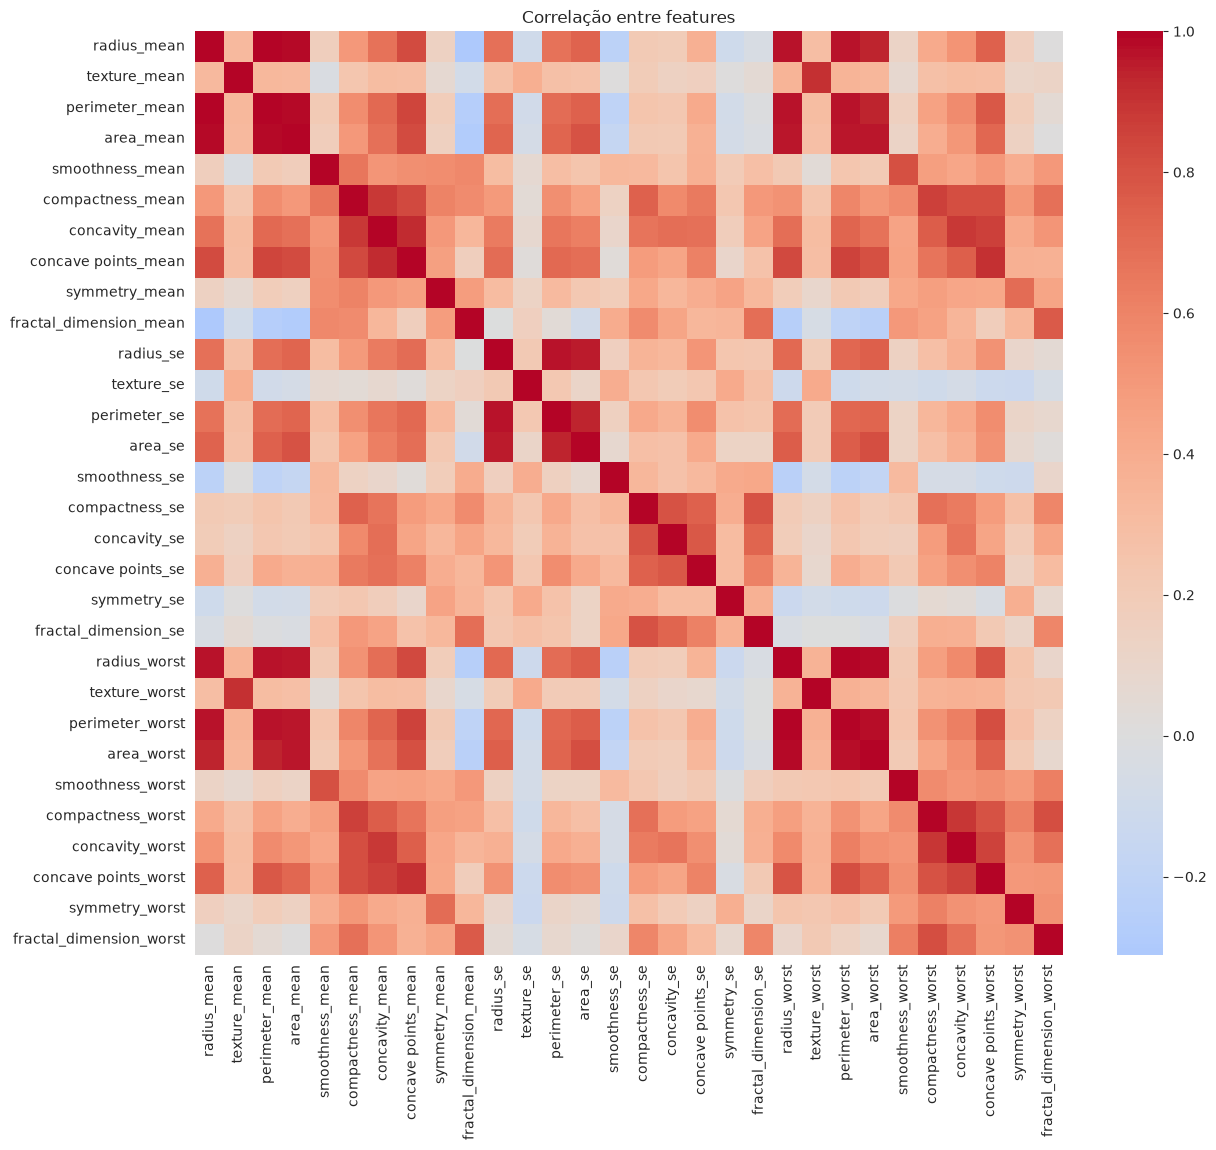

In [154]:
# Heatmap de correlação entre as features (identifica multicolinearidade forte,
# comum entre radius/perimeter/area, por exemplo)
feature_cols = [c for c in df_clf.columns if c != "diagnosis"]
plt.figure(figsize=(14, 12))
sns.heatmap(df_clf[feature_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlação entre features")
plt.show()


**Multicolinearidade:** heatmap de correlação entre as 30 features. Como as variáveis
derivam das mesmas medidas geométricas em três formas (`_mean`, `_se`, `_worst`) —
ex.: `radius_mean`, `perimeter_mean` e `area_mean` são matematicamente dependentes
(perímetro e área são funções do raio) — espera-se correlação forte entre subgrupos.

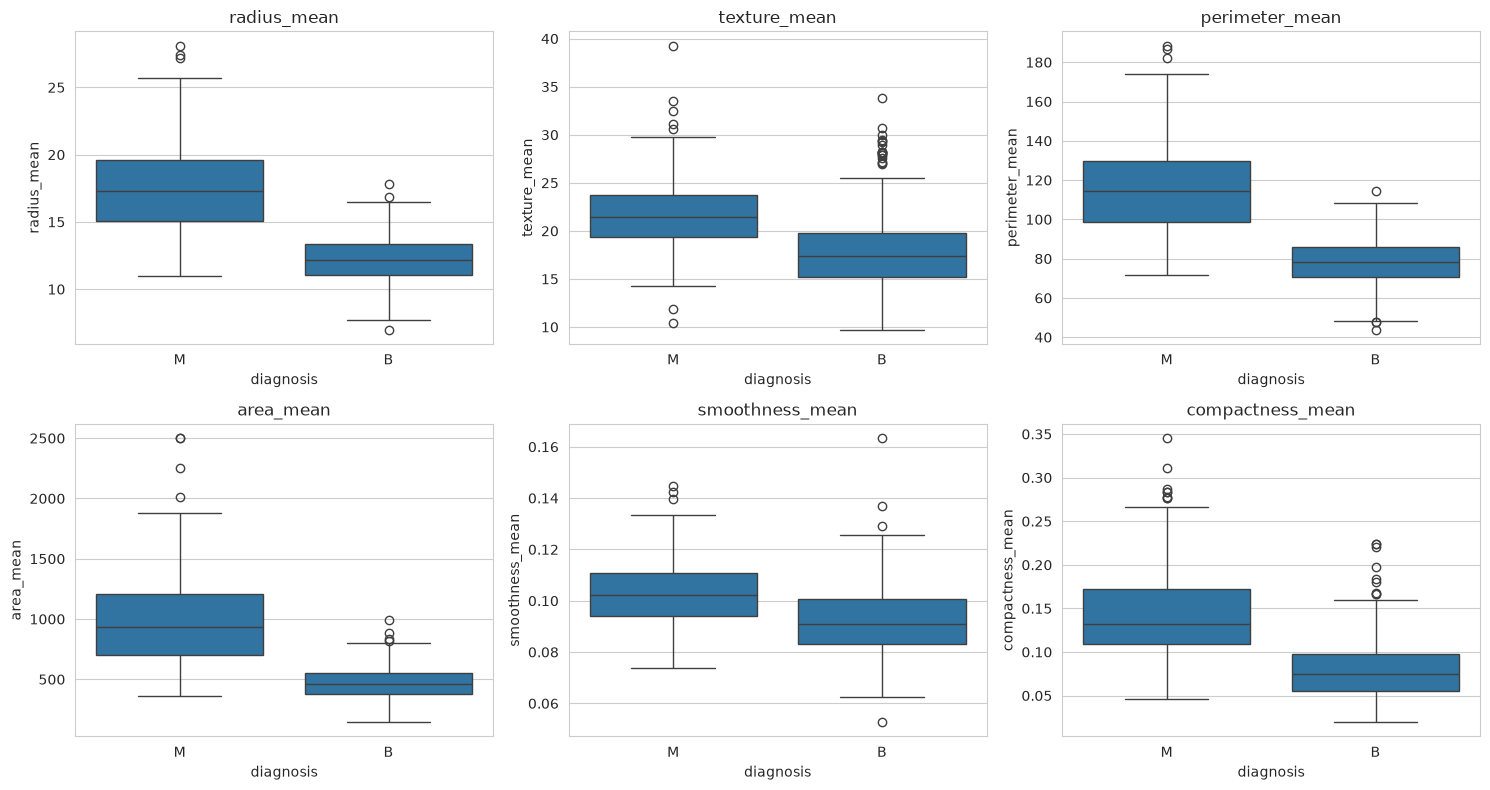

In [155]:
# Distribuição de algumas features-chave por diagnóstico
key_feats = [c for c in feature_cols if "_mean" in c][:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.ravel(), key_feats):
    sns.boxplot(data=df_clf, x="diagnosis", y=feat, ax=ax)
    ax.set_title(feat)
plt.tight_layout()
plt.show()


**Separabilidade das classes:** boxplots de features `_mean` por `diagnosis`,
para inspecionar visualmente o grau de sobreposição entre as distribuições de
benigno e maligno — um indicador informal do quão discriminativa é cada feature
antes de qualquer modelagem.

Ordenando pelo grau de separação visual (menor sobreposição de caixas = maior
poder discriminativo isolado):
1. **`area_mean`** — separação quase total, praticamente sem sobreposição de caixas.
2. **`perimeter_mean`** e **`radius_mean`** — separação muito forte, sobreposição mínima.
3. **`compactness_mean`** — separação boa: mediana de maligno nitidamente acima da
   de benigno, com sobreposição moderada entre os quartis.
4. **`texture_mean`** — separação visível, porém mais discreta, com maior
   sobreposição entre os quartis das duas classes.
5. **`smoothness_mean`** — a mais fraca das seis, com sobreposição considerável.

Mesmo as features mais fracas isoladamente (`texture_mean`, `smoothness_mean`)
contribuem para o desempenho do modelo, que combina todas as 30 variáveis
simultaneamente em vez de depender de uma única feature discriminativa — isso
ajuda a explicar por que a acurácia final ficou tão alta mesmo sem engenharia de
features adicional.


## 2.2 Pré-processamento

**Validação de schema:** mesma checagem de consistência de colunas entre `train2.csv`
e `test2.csv` aplicada na Parte 1.

**Codificação do alvo:** `diagnosis` (categórico: `"M"`/`"B"`) mapeado para binário
(`1`/`0`) via `map({"M": 1, "B": 0})`. Necessário porque os classificadores do
scikit-learn operam sobre rótulos numéricos.

**Padronização:** como as 30 features são todas numéricas mas em escalas muito
diferentes (ex.: `area_mean` da ordem de milhares vs. `smoothness_mean` da ordem de
0.1), aplica-se `SimpleImputer(strategy="median")` → `StandardScaler()`. Isso é
crítico para cálculos que seriam
dominados pelas features de maior magnitude sem a normalização.

In [156]:
assert set(test_clf.columns) == set(df_clf.columns) - {"diagnosis"}, "colunas de test2.csv não batem com train2.csv"

y_clf = df_clf["diagnosis"].map({"M": 1, "B": 0})
X_clf = df_clf.drop(columns=["diagnosis"])

preprocessor_clf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])


## 2.3 Modelos de Inferência

Foram comparados 8 classificadores:

| Modelo | Mecanismo | Observação |
|---|---|---|
| `LogisticRegression` | modela log-odds da classe como combinação linear das features | baseline forte, coeficientes interpretáveis como log-odds ratio |
| `KNeighborsClassifier` | classifica pela classe majoritária entre os *k* vizinhos mais próximos | sensível à escala; requer padronização |
| `GaussianNB` | aplica o teorema de Bayes assumindo independência condicional e distribuição normal das features | rápido, mas a suposição de independência é violada dada a colinearidade observada |
| `SVC` (kernel linear e RBF) | encontra o hiperplano de máxima margem entre classes; RBF projeta para espaço de maior dimensão para separar classes não-linearmente separáveis | `probability=True` habilita estimativa de probabilidade via calibração de Platt |
| `DecisionTreeClassifier` | particiona o espaço por divisões que maximizam pureza (Gini/entropia) | interpretável, mas propenso a overfitting isolado |
| `RandomForestClassifier` | ensemble bagging de árvores | reduz variância, robusto a colinearidade |
| `GradientBoostingClassifier` | ensemble boosting sequencial | reduz viés, geralmente forte em dados tabulares |

In [ ]:
# Split treino/holdout (80/20), estratificado por classe para preservar proporção original
Xc_train, Xc_val, yc_train, yc_val = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

#Candidatos a classificador
#SVM_linear e SVM_rbf usam CalibrateClassifierCV para o ajuste de treshold feito abaixo
clf_models = {
    "LogisticRegression": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "GaussianNB": GaussianNB(),
    "SVM_linear": CalibratedClassifierCV(SVC(kernel="linear", random_state=RANDOM_STATE), ensemble=False),
    "SVM_rbf": CalibratedClassifierCV(SVC(kernel="rbf", random_state=RANDOM_STATE), ensemble=False),
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}


## 2.4 Avaliação: Acurácia e Matriz de Confusão

**Protocolo:** validação cruzada K-Fold (k=5) sobre acurácia (`cross_val_score` com
`scoring="accuracy"`), reportando média e desvio-padrão por modelo — mesmo racional
de estabilidade estatística descrito na Parte 1.

**Por que acurácia sozinha não basta:** com classes desbalanceadas (63%/37%), um
classificador trivial que sempre prevê "benigno" atinge 63% de acurácia sem qualquer
capacidade discriminativa. 


O modelo final é reajustado em 100% do `train2.csv` antes da inferência sobre `test2.csv`,
pelo mesmo racional de maximização de dados de treino descrito na Parte 1.

In [ ]:
# Validação cruzada (5-fold) de todos os candidatos, comparados por acurácia
skf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results_clf = []

for name, model in clf_models.items():
    pipe = Pipeline([("prep", preprocessor_clf), ("model", model)])
    acc_scores = cross_val_score(pipe, X_clf, y_clf, cv=skf, scoring="accuracy")
    results_clf.append({"modelo": name, "acc_mean": acc_scores.mean(), "acc_std": acc_scores.std()})
    print(f"{name:20s} acurácia = {acc_scores.mean():.4f} +/- {acc_scores.std():.4f}")

results_clf_df = pd.DataFrame(results_clf).sort_values("acc_mean", ascending=False)
results_clf_df


LogisticRegression   acurácia = 0.9771 +/- 0.0090
KNN                  acurácia = 0.9595 +/- 0.0191
GaussianNB           acurácia = 0.9367 +/- 0.0152
SVM_linear           acurácia = 0.9754 +/- 0.0067
SVM_rbf              acurácia = 0.9771 +/- 0.0090
DecisionTree         acurácia = 0.9332 +/- 0.0162
RandomForest         acurácia = 0.9631 +/- 0.0086
GradientBoosting     acurácia = 0.9649 +/- 0.0096


,modelo,acc_mean,acc_std
0,LogisticRegression,0.977146,0.008964
4,SVM_rbf,0.977146,0.008964
3,SVM_linear,0.975376,0.006664
7,GradientBoosting,0.964850,0.009610
6,RandomForest,0.963096,0.008583
1,KNN,0.959525,0.019092
2,GaussianNB,0.936718,0.015151
5,DecisionTree,0.933225,0.016236


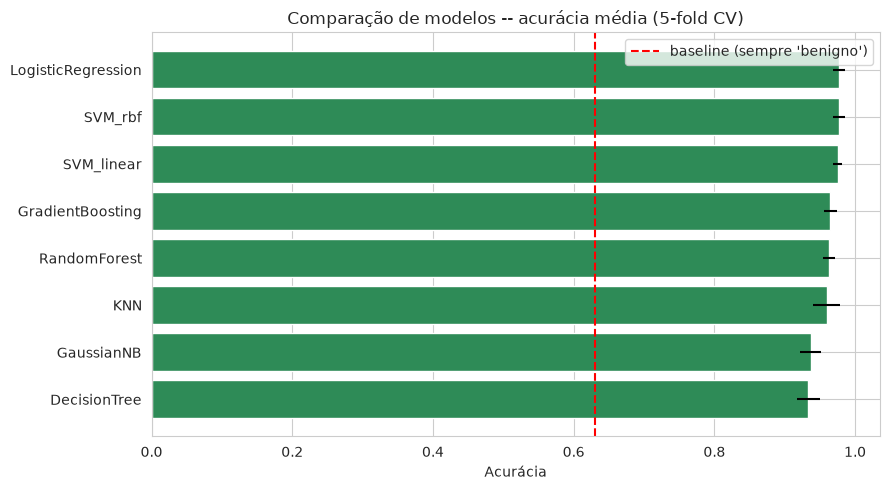

In [ ]:
# Comparação visual dos modelos por acurácia média com baseline trivial como referência mínima
plt.figure(figsize=(9, 5))
plt.barh(results_clf_df["modelo"], results_clf_df["acc_mean"],
         xerr=results_clf_df["acc_std"], color="seagreen")
plt.gca().invert_yaxis()
plt.axvline(0.63, color="red", linestyle="--", label="baseline (sempre 'benigno')")
plt.legend()
plt.title("Comparação de modelos -- acurácia média (5-fold CV)")
plt.xlabel("Acurácia")
plt.tight_layout()
plt.show()


**Leitura do gráfico:** `LogisticRegression` e `SVM_rbf` empataram na acurácia média (97,71%), seguidos de perto por `SVM_linear` (97,54%), a diferença entre os três está dentro da margem de desvio-padrão entre folds, ou seja, estatisticamente eles são equivalentes, não há um vencedor claro. Em seguida vêm os ensembles de árvore. Todos os modelos, mesmo o mais fraco, ficaram muito acima do baseline de 63% marcado pela linha vermelha.


Melhor modelo por CV: LogisticRegression
Acurácia (holdout): 0.9649
              precision    recall  f1-score   support

 Benigno (0)       0.96      0.99      0.97        72
 Maligno (1)       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



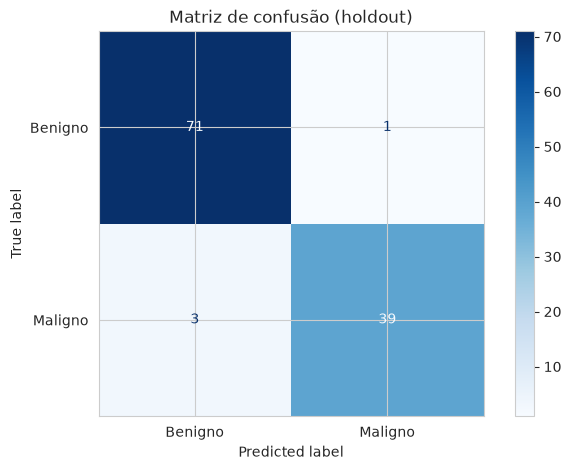

Verdadeiros negativos (benigno correto): 71
Falsos positivos (benigno previsto como maligno): 1
Falsos negativos (maligno previsto como benigno) -- o mais grave clinicamente: 3
Verdadeiros positivos (maligno correto): 39


In [ ]:
# Seleciona modelo com maior acurácia média, treina e avalia holdout
best_clf_name = results_clf_df.iloc[0]["modelo"]
print("Melhor modelo por CV:", best_clf_name)

best_clf_pipe = Pipeline([("prep", preprocessor_clf), ("model", clf_models[best_clf_name])])
best_clf_pipe.fit(Xc_train, yc_train)
yc_pred = best_clf_pipe.predict(Xc_val)

print(f"Acurácia (holdout): {accuracy_score(yc_val, yc_pred):.4f}")
print(classification_report(yc_val, yc_pred, target_names=["Benigno (0)", "Maligno (1)"]))

cm = confusion_matrix(yc_val, yc_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benigno", "Maligno"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusão (holdout)")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Verdadeiros negativos (benigno correto): {tn}")
print(f"Falsos positivos (benigno previsto como maligno): {fp}")
print(f"Falsos negativos (maligno previsto como benigno) -- o mais grave clinicamente: {fn}")
print(f"Verdadeiros positivos (maligno correto): {tp}")


**Matriz de confusão** (`confusion_matrix`): contagem de Verdadeiros Positivos (VP),
Verdadeiros Negativos (VN), Falsos Positivos (FP) e Falsos Negativos (FN) no holdout
de teste (20%, estratificado por classe via `stratify=y_clf` para preservar a
proporção original em ambos os splits).

  O modelo cometeu 3 erros no total, todos do mesmo tipo: **3 falsos negativos** (tumores
malignos classificados como benignos) e **1 falso positivo**. Isso resulta em recall de
92.9% para a classe maligna (39/42) e precisão de 98,6% para benigna.

Esse padrão de erro é o pior possível clinicamente: um falso positivo leva a exames
adicionais desnecessários, enquanto um falso negativo significa que um tumor canceroso
não foi identificado, atrasando o diagnóstico e o tratamento do paciente. 

Isso reforça por que acurácia sozinha não é suficiente nesse contexto: um modelo com a
mesma acurácia mas com os erros concentrados em falsos positivos seria preferível do
ponto de vista clínico, já que erra por excesso de cautela em vez de
deixar de detectar um câncer real.



### Por que ajustar o threshold de decisão?
A matriz de confusão na célula acima mostrou 3 falsos negativos e apenas um falso positivo. Por padrão, o método `.predict()` de um classificados usa um threshold implícito de 0.5 sobre a probabilidade estimada: se `P(maligno) >= 0.5`, classifica como maligno, senão como benigno. Esse corte de 0.5 assume que os dois tipos de erro têm o mesmo custo - o que não é verdade neste problema: um falso negativo atrasa o diagnóstico de um câncer real. Por isso, faz sentido testar thresholds menores que 0.5, que tornam o modelo mais propenso a classificar como maligno em caso de dúvida.Essa é a lógica implementada na célula
abaixo, calculada sobre `probs_val`, as probabilidades previstas pelo
`best_clf_pipe` no holdout de 20%, o mesmo split usado na matriz de confusão anterior, garantindo que a comparação entre thresholds seja justo (nenhum dado extra é usado).

In [ ]:
# Ajuste de threshold: priorizando recall da classe maligna (1)
# Vamos testar valores menores, que tornam o modelo mais
# propenso a classificar como maligno em caso de dúvida.

probs_val = best_clf_pipe.predict_proba(Xc_val)[:, 1]  # probabilidade de ser maligno

thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]
threshold_results = []

for t in thresholds:
    preds_t = (probs_val >= t).astype(int)
    cm_t = confusion_matrix(yc_val, preds_t)
    tn, fp, fn, tp = cm_t.ravel()
    recall_malignant = tp / (tp + fn)
    precision_malignant = tp / (tp + fp) if (tp + fp) > 0 else 0
    acc = accuracy_score(yc_val, preds_t)
    threshold_results.append({
        "threshold": t, "VP": tp, "FN": fn, "FP": fp, "VN": tn,
        "recall_maligno": recall_malignant, "precisao_maligno": precision_malignant,
        "acuracia": acc
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,threshold,VP,FN,FP,VN,recall_maligno,precisao_maligno,acuracia
0,0.5,39,3,1,71,0.928571,0.975000,0.964912
1,0.4,40,2,1,71,0.952381,0.975610,0.973684
2,0.3,41,1,1,71,0.976190,0.976190,0.982456
3,0.2,41,1,4,68,0.976190,0.911111,0.956140
4,0.1,41,1,5,67,0.976190,0.891304,0.947368


**Leitura da tabela:** reduzir o threshold de 0.5 para 0.3 elimina 2 dos 3 falsos negativos (de 3 para 1), elevando o recall da classe maligna de 92,9% para 97,6%, **sem custar nada em precisão** (que permanece em ~97,6%), o único falso positivo já estava presente mesmo no threshold padrão. A partir de 0.3, thresholds ainda menores (0.2, 0.1) não reduzem mais os falsos negativos (estabilizados em 1), mas aumentam os falsos positivos de 1 para 4 e depois 5, derrubando a precisão de 97,6% para 91% e 89%. Ou seja, `threshold = 0.3` é o
ponto de equilíbrio.


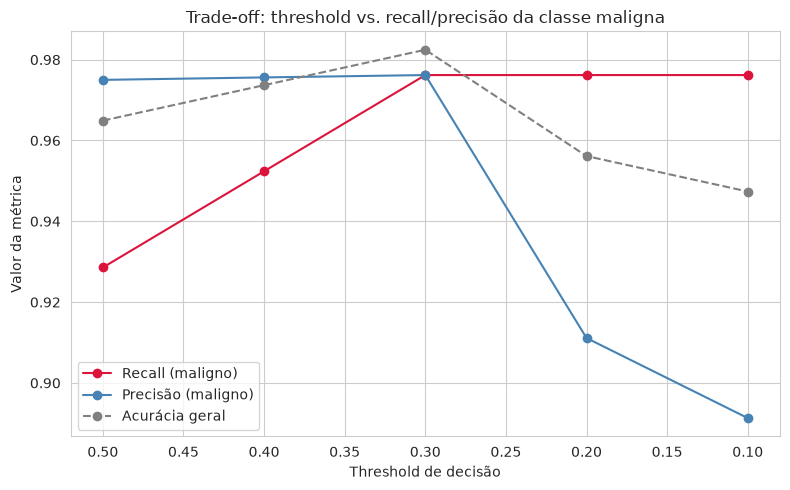

In [162]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(threshold_df["threshold"], threshold_df["recall_maligno"], marker="o", label="Recall (maligno)", color="crimson")
ax1.plot(threshold_df["threshold"], threshold_df["precisao_maligno"], marker="o", label="Precisão (maligno)", color="steelblue")
ax1.plot(threshold_df["threshold"], threshold_df["acuracia"], marker="o", label="Acurácia geral", color="gray", linestyle="--")
ax1.set_xlabel("Threshold de decisão")
ax1.set_ylabel("Valor da métrica")
ax1.set_title("Trade-off: threshold vs. recall/precisão da classe maligna")
ax1.legend()
ax1.invert_xaxis()
plt.tight_layout()
plt.show()

**Leitura do gráfico:** as três curvas (recall, precisão e acurácia) sobem juntas conforme o threshold desce de 0.5 para 0.3, atingindo o pico simultâneo nesse ponto, o "cotovelo" da curva. Abaixo de 0.3, a curva de precisão (azul) despenca visivelmente enquanto a de recall (vermelha) já achatou, sinalizando que reduzir ainda mais o threshold só piora o equilíbrio geral sem ganho adicional em detectar malignos. Esse cruzamento visual é o que confirma `0.3` como escolha justificada, e não arbitrária.


Threshold = 0.3
Acurácia: 0.9825
              precision    recall  f1-score   support

 Benigno (0)       0.99      0.99      0.99        72
 Maligno (1)       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



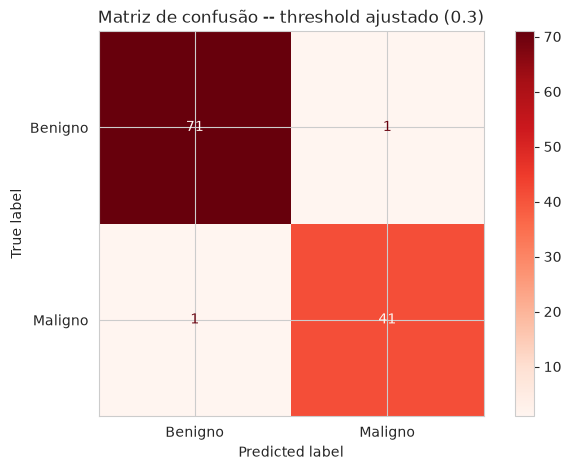

In [163]:
# Escolhido com base na tabela acima: menor threshold que zera (ou reduz ao máximo)
# os falsos negativos sem custar demais em precisão/acurácia geral.
NEW_THRESHOLD = 0.3  # ajuste este valor observando threshold_df

preds_new = (probs_val >= NEW_THRESHOLD).astype(int)

print(f"Threshold = {NEW_THRESHOLD}")
print(f"Acurácia: {accuracy_score(yc_val, preds_new):.4f}")
print(classification_report(yc_val, preds_new, target_names=["Benigno (0)", "Maligno (1)"]))

cm_new = confusion_matrix(yc_val, preds_new)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_new, display_labels=["Benigno", "Maligno"])
disp.plot(cmap="Reds")
plt.title(f"Matriz de confusão -- threshold ajustado ({NEW_THRESHOLD})")
plt.show()

**Leitura do resultado final:** com `threshold = 0.3`, a matriz de confusão passa a ter 1 falso negativo e 1 falso positivo e a acurácia no holdout sobe de 96,49% para 98,25%. Do ponto de vista clínico, essa é uma troca favorável: reduzimos o erro mais grave (deixar de detectar um câncer real) à custa de, no máximo, um exame adicional desnecessário, e ainda de quebra a acurácia geral melhorou, não piorou.

In [164]:
# Reajusta o melhor pipeline em TODO o train2.csv e gera as previsões para o test2.csv
final_clf_pipe = Pipeline([("prep", preprocessor_clf), ("model", clf_models[best_clf_name])])
final_clf_pipe.fit(X_clf, y_clf)

test_pred_clf = final_clf_pipe.predict(test_clf)

submission_clf = pd.DataFrame({
    "id": range(len(test_pred_clf)),   
    "diagnosis": test_pred_clf         
})
submission_clf.to_csv("classiicacao/submission.csv", index=False)
submission_clf.head()


,id,diagnosis
0,0,0
1,1,0
2,2,0
3,3,1
4,4,0


- **Precision, Recall e F1-score** por classe (`classification_report`): particularmente
  o **recall da classe maligna** (VP / (VP + FN)) é a métrica clinicamente mais crítica
  neste problema — um Falso Negativo (tumor maligno classificado como benigno) tem custo
  assimétrico muito maior que um Falso Positivo, pois atrasa diagnóstico e tratamento.

In [165]:
# Checagem final antes de submeter
assert len(submission_clf) == len(test_clf), "número de linhas não bate com test2.csv"
assert submission_clf.isnull().sum().sum() == 0, "há NaN na submissão"
assert set(submission_clf["diagnosis"].unique()).issubset({0, 1}), "valores fora de {0,1}"
print("OK -- submission.csv da classificação pronto para o Kaggle.")


OK -- submission.csv da classificação pronto para o Kaggle.
